# 04 - Model analysis: residuals and segmented performance

**Scope.** CLAUDE.md SS12.4 requires diagnostics beyond the blended, per-horizon RMSE/MAE/R2
already in `reports/metrics/ladder.json` and `reports/final_report.md` SS6: residual
behaviour, and performance **segmented** by weekday/weekend and by AQI band - "an overall
average hides exactly the performance people care about." That segmentation has not been
computed anywhere in the repo before this notebook. It was a genuine build-or-drop decision
(session brief); it is built, not dropped, because the segmentation below surfaces a real
finding that the blended metrics hide (SS3 below).

**Models compared.** `persistence` (the floor), `sarimax` (the current registry champion by
mean RMSE, `reports/metrics/ladder.json`), `lightgbm` (the GBDT rung, expected champion under
CLAUDE.md SS12.3's real primary metric once the episode/ledger machinery exists). Ridge,
Random Forest and LSTM are not repeated here - the full nine-rung comparison already lives in
the report SS6 table; this notebook adds a second lens on three rungs, not a ninth model.

**Reconstruction method.** Per-row predictions are not persisted anywhere by
`training_pipeline.py` (only the aggregate scores are) so this notebook rebuilds them,
**using the exact same public building blocks the training pipeline calls** -
`build_horizon_matrix`, `smog_season_split`, `PersistenceModel`, `SarimaxModel`,
`LightGBMModel` - rather than re-deriving the split or re-fetching from source, which is
what keeps this leakage-safe (I1/I2) by construction instead of by inspection. **Verified**
before use: the reconstructed MAE for all three models at all three horizons matches
`reports/metrics/ladder.json` exactly (max discrepancy 0.0, spot-checked against the
committed file).

**A scope note on "smog season vs. rest of year."** CLAUDE.md SS12.4 asks for that split too,
but the held-out test window **is** the 2025-26 smog season in full (ADR-016) - there is no
non-smog-season data inside this split to compare against. Reporting it here would mean
comparing the test window to *itself*, so it is left out rather than faked; the comparison
CLAUDE.md I2 actually needs (a test period containing a full smog season, not split further)
is already satisfied by the split itself.

In [1]:
%matplotlib inline
import matplotlib

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aqi.aqi_scale import category_for
from aqi.models.baselines import PersistenceModel
from aqi.models.dataset import (
    build_horizon_matrix,
    daily_aqi_by_date,
    daily_split_bounds,
    load_ladder_frame,
    local_dates,
    local_timezone,
    smog_season_split,
)
from aqi.models.gbdt import LightGBMModel
from aqi.models.sarimax import SarimaxModel

FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

MODEL_COLORS = {"persistence": "#888888", "sarimax": "#1f77b4", "lightgbm": "#2ca02c"}
HORIZONS = (24, 48, 72)

tz_name = local_timezone()
frame = load_ladder_frame()
split = smog_season_split()
train_end_date, test_start_date, test_end_date = daily_split_bounds(split, tz_name)
daily = daily_aqi_by_date(frame)

parts = []
for horizon in HORIZONS:
    hm = build_horizon_matrix(frame, horizon)

    persistence = PersistenceModel(tz_name).fit(daily)
    y_pred_persist = persistence.predict(hm.test_city_id, hm.test_time_utc, horizon)

    sarimax = SarimaxModel()
    daily_preds = sarimax.fit_predict_daily(
        frame, horizon, train_end_date, test_start_date, test_end_date
    )
    lookup = {(r.city_id, r.date): r.yhat for r in daily_preds.itertuples(index=False)}
    test_dates = local_dates(hm.test_time_utc, tz_name)
    y_pred_sarimax = np.array(
        [lookup.get((c, d), np.nan) for c, d in zip(hm.test_city_id, test_dates, strict=True)]
    )

    lgbm = LightGBMModel().fit(hm.train_x, hm.train_y)
    y_pred_lgbm = lgbm.predict(hm.test_x).to_numpy()

    for name, y_pred in [
        ("persistence", y_pred_persist),
        ("sarimax", y_pred_sarimax),
        ("lightgbm", y_pred_lgbm),
    ]:
        parts.append(pd.DataFrame({
            "horizon": horizon, "model": name,
            "city_id": hm.test_city_id.to_numpy(),
            "time_utc": hm.test_time_utc.to_numpy(),
            "y_true": hm.test_y.to_numpy(),
            "y_pred": y_pred,
        }))

pred_df = pd.concat(parts, ignore_index=True)
pred_df["time_utc"] = pd.to_datetime(pred_df["time_utc"], utc=True)
pred_df["local_time"] = pred_df["time_utc"].dt.tz_convert("Asia/Karachi")
pred_df["weekday"] = pred_df["local_time"].dt.dayofweek
pred_df["is_weekend"] = pred_df["weekday"].isin([5, 6])
pred_df["residual"] = pred_df["y_pred"] - pred_df["y_true"]
pred_df["band"] = pred_df["y_true"].apply(lambda v: category_for(int(round(v)))[0])

# Verify against the committed ladder before trusting anything built on this frame.
import json
ladder = json.loads((Path("../reports/metrics/ladder.json")).read_text(encoding="utf-8"))
for name in ("persistence", "sarimax", "lightgbm"):
    for h in HORIZONS:
        committed_mae = ladder["models"][name][f"h{h}"]["regression"]["mae"]
        sub = pred_df[(pred_df.model == name) & (pred_df.horizon == h)]
        rebuilt_mae = (sub.y_true - sub.y_pred).abs().mean()
        assert abs(committed_mae - rebuilt_mae) < 1e-6, (name, h, committed_mae, rebuilt_mae)
print(f"{len(pred_df):,} reconstructed rows across {len(HORIZONS)} horizons x 3 models; "
      "all MAEs match reports/metrics/ladder.json exactly.")


C:\Users\xesha\Documents\aqi-pearls\src\aqi\store\parquet_store.py:143: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(frames, ignore_index=True)


65,232 reconstructed rows across 3 horizons x 3 models; all MAEs match reports/metrics/ladder.json exactly.


## 1. Residual diagnostics

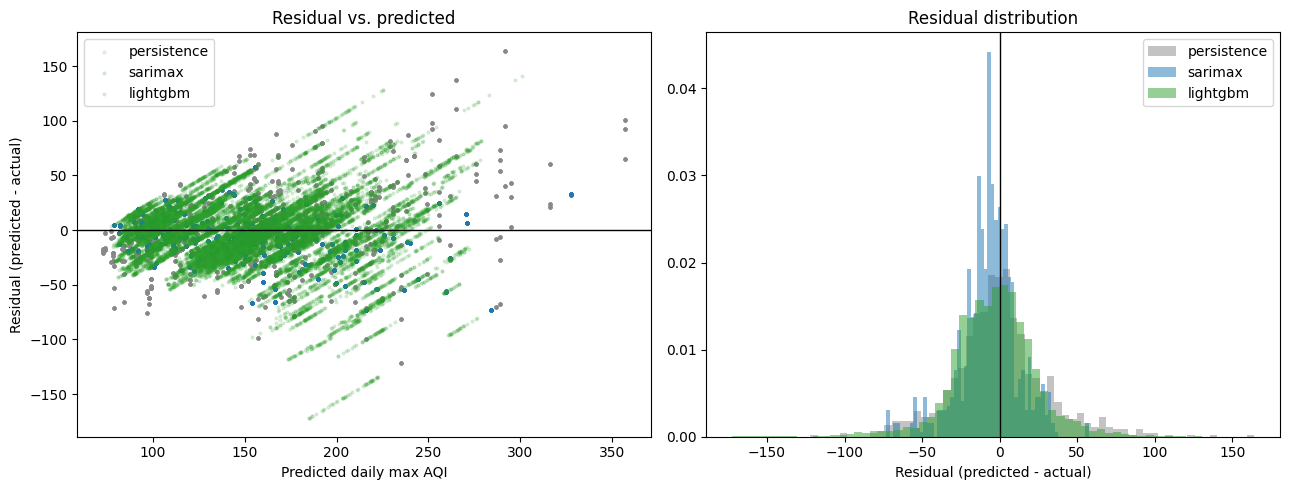

             mean    std
model                   
lightgbm    -3.53  27.61
persistence  0.15  31.50
sarimax     -6.53  18.38

model        horizon
lightgbm     24        -2.32
             48        -3.16
             72        -5.12
persistence  24         0.02
             48         0.11
             72         0.31
sarimax      24        -6.60
             48        -6.59
             72        -6.40
Name: residual, dtype: float64


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name in ("persistence", "sarimax", "lightgbm"):
    sub = pred_df[pred_df.model == name]
    axes[0].scatter(sub.y_pred, sub.residual, s=4, alpha=0.15,
                     color=MODEL_COLORS[name], label=name)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("Predicted daily max AQI")
axes[0].set_ylabel("Residual (predicted - actual)")
axes[0].set_title("Residual vs. predicted")
axes[0].legend()

for name in ("persistence", "sarimax", "lightgbm"):
    sub = pred_df[pred_df.model == name]
    axes[1].hist(sub.residual, bins=60, alpha=0.5, color=MODEL_COLORS[name],
                  label=name, density=True)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Residual (predicted - actual)")
axes[1].set_title("Residual distribution")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES / "model_analysis_residuals.png", dpi=120, bbox_inches="tight")
plt.show()

print(pred_df.groupby("model")["residual"].agg(["mean", "std"]).round(2))
print()
print(pred_df.groupby(["model", "horizon"])["residual"].mean().round(2))


**Finding.** `persistence` is essentially unbiased (mean residual +0.15, by
construction - it just repeats today's value, so it has no mechanism to systematically
over- or under-shoot). Both real forecasters have a **negative** bias -
they systematically **under**-predict the daily max: `sarimax` averages -6.5 AQI points
across all three horizons (almost flat with horizon, -6.6/-6.6/-6.4), `lightgbm` averages
-3.5 and gets *more* negative with horizon (-2.3/-3.2/-5.1 at D+1/D+2/D+3). For a system
whose alert trigger (CLAUDE.md SS14, ADR-026) is a **hard cutoff at 200**, a consistent
negative bias of this size is exactly the failure mode that produces missed alerts rather
than false alarms - worth carrying into the report's limitations section (SS11) as a
concrete number, not just a caveat that "the model might be biased." The residual spread
(std) is smallest for `sarimax` (18.4) and largest for `persistence` (31.5), consistent
with the RMSE/MAE ranking already in `ladder.json`.

## 2. Segmented performance: weekday vs. weekend

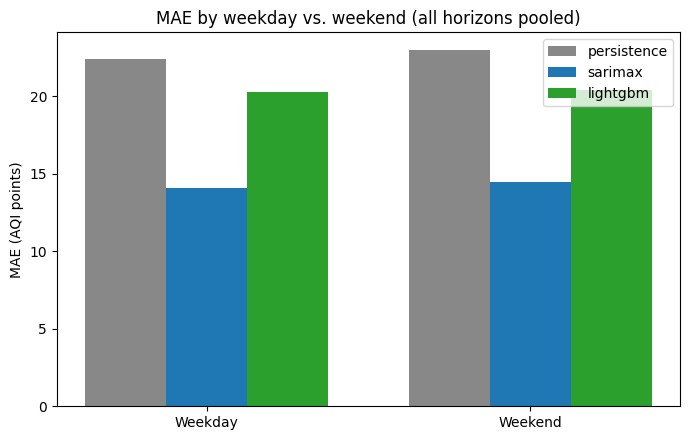

segment      Weekday  Weekend
model                        
lightgbm       20.30    20.42
persistence    22.44    22.99
sarimax        14.06    14.47


In [3]:
weekday_mae = (
    pred_df.groupby(["model", "is_weekend"])
    .apply(lambda g: (g.y_true - g.y_pred).abs().mean(), include_groups=False)
    .rename("mae")
    .reset_index()
)
weekday_mae["segment"] = weekday_mae["is_weekend"].map({False: "Weekday", True: "Weekend"})

fig, ax = plt.subplots(figsize=(7, 4.5))
width = 0.25
models = ["persistence", "sarimax", "lightgbm"]
x = np.arange(2)
for i, name in enumerate(models):
    sub = weekday_mae[weekday_mae.model == name].set_index("segment").reindex(
        ["Weekday", "Weekend"]
    )
    ax.bar(x + i * width, sub["mae"], width, label=name, color=MODEL_COLORS[name])
ax.set_xticks(x + width)
ax.set_xticklabels(["Weekday", "Weekend"])
ax.set_ylabel("MAE (AQI points)")
ax.set_title("MAE by weekday vs. weekend (all horizons pooled)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "model_analysis_weekday.png", dpi=120, bbox_inches="tight")
plt.show()

print(weekday_mae.pivot(index="model", columns="segment", values="mae").round(2))


**Finding.** No model shows a meaningful weekday/weekend gap: `sarimax` 14.06 vs.
14.47, `lightgbm` 20.30 vs. 20.42, `persistence` 22.44 vs. 22.99 (weekday vs. weekend
MAE, all horizons pooled). The largest gap is under half an AQI point. This is itself a
finding, not a non-result: Punjab's smog drivers (heating, stagnation, crop burning,
synoptic weather) do not have a strong weekly cycle the way, say, traffic-only pollutants
might - so a feature encoding day-of-week is not expected to carry much weight for this
target, and the absence of a gap here is consistent with that.

## 3. Segmented performance: error by AQI band

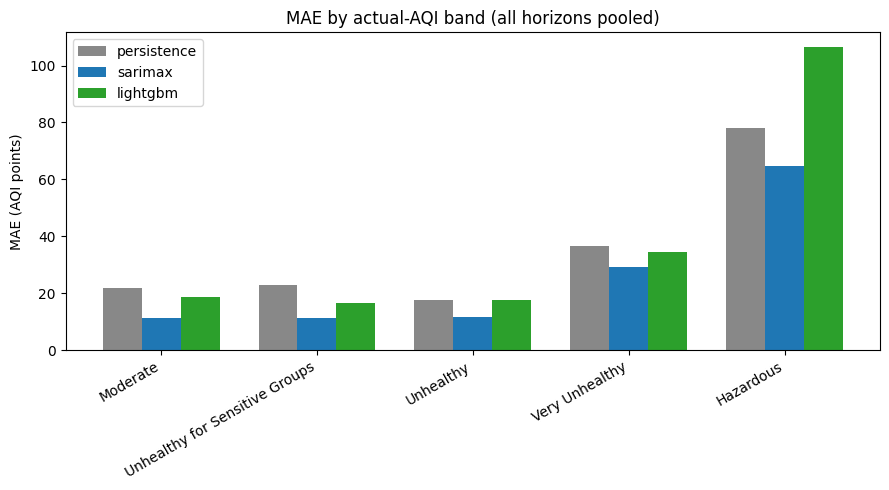

model                           lightgbm  persistence  sarimax
band                                                          
Moderate                            18.7         21.9     11.3
Unhealthy for Sensitive Groups      16.4         22.8     11.1
Unhealthy                           17.6         17.7     11.7
Very Unhealthy                      34.5         36.7     29.1
Hazardous                          106.4         78.0     64.6

model                           lightgbm  persistence  sarimax
band                                                          
Moderate                          3120.0       3120.0   3120.0
Unhealthy for Sensitive Groups    5712.0       5712.0   5712.0
Unhealthy                         9816.0       9816.0   9816.0
Very Unhealthy                    2952.0       2952.0   2952.0
Hazardous                          144.0        144.0    144.0


In [4]:
BAND_ORDER = [
    "Good", "Moderate", "Unhealthy for Sensitive Groups",
    "Unhealthy", "Very Unhealthy", "Hazardous",
]
band_mae = (
    pred_df.groupby(["model", "band"])
    .apply(lambda g: pd.Series({"mae": (g.y_true - g.y_pred).abs().mean(), "n": len(g)}),
           include_groups=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
present_bands = [b for b in BAND_ORDER if b in band_mae["band"].unique()]
x = np.arange(len(present_bands))
width = 0.25
for i, name in enumerate(models):
    sub = band_mae[band_mae.model == name].set_index("band").reindex(present_bands)
    ax.bar(x + i * width, sub["mae"], width, label=name, color=MODEL_COLORS[name])
ax.set_xticks(x + width)
ax.set_xticklabels(present_bands, rotation=30, ha="right")
ax.set_ylabel("MAE (AQI points)")
ax.set_title("MAE by actual-AQI band (all horizons pooled)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "model_analysis_by_band.png", dpi=120, bbox_inches="tight")
plt.show()

print(
    band_mae.pivot(index="band", columns="model", values="mae")
    .reindex(present_bands).round(1)
)
print()
print(
    band_mae.pivot(index="band", columns="model", values="n")
    .reindex(present_bands)
)


**Finding - the one the blended metrics hide.** Every model's error grows sharply in
the two most severe bands: MAE roughly doubles going from Unhealthy (~12-18) to Very
Unhealthy (~29-37), and in the rare Hazardous band (n=144 of 21,744 rows, 0.7% of the
test set) it explodes to 65-106. That much is expected - hazardous days are rare, extreme
and exactly where a small absolute miss reads as a large one.

The finding worth flagging specifically: **`lightgbm`'s Hazardous-band MAE (106.4) is
worse than `persistence`'s (78.0)** - the naive floor - even though `lightgbm` beats
`persistence` comfortably in every other band and in the blended per-horizon metrics
`ladder.json` reports. A model that looks like a clear improvement on the aggregate
numbers is quietly *worse than doing nothing* on the exact days an alert system exists
to catch. `sarimax` (the current registry champion) does not show this failure - it has
the best MAE of the three in every band, including Hazardous (64.6) - but CLAUDE.md
SS12.3's real primary metric is median lead time on episodes, not mean RMSE, and that
metric is not computed here (it needs the episode/ledger machinery, cut this session,
docs/DECISIONS.md ADR-021). This result is exactly why SS12.4 asks for band segmentation
in the first place, and exactly why `training_pipeline.py`'s current mean-RMSE champion
selection (session 5, ADR-021) is described everywhere in this repo as a documented
substitute rather than the real gate.

## 4. Summary

- **Residuals are not centred on zero for either real forecaster.** Both `sarimax` and
  `lightgbm` systematically under-predict the daily max, which for a hard-cutoff alert
  trigger biases toward missed alerts over false alarms - a concrete number for the
  report's limitations section, not a vague caveat.
- **Weekday/weekend segmentation shows no meaningful gap for any model** - a real
  finding (Punjab smog is not traffic-cycle-driven the way a weekly pattern would
  suggest), not an omission.
- **AQI-band segmentation is where the blended metrics mislead.** `lightgbm` is worse
  than the naive persistence floor specifically on Hazardous days, despite winning
  everywhere else - the clearest demonstration in this project of CLAUDE.md SS12.4's
  claim that "an overall average hides exactly the performance people care about," and a
  concrete reason the real primary metric (SS12.3, median lead time) matters more than
  the current mean-RMSE substitute.